In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pdb
import mat73

In [3]:
# for .mat files saved in MATLAB v7.2 or earlier (most common)
# data = sio.loadmat('/Users/avinashranjan/Desktop/UT Austin/Goris lab/Model_V1_damage/V1DamageModel/SpikeData.mat', simplify_cells=True)
# dataTest = sio.loadmat('/Users/avinashranjan/Desktop/UT Austin/Goris lab/Model_V1_damage/V1DamageModel/SpikeDataTest.mat', simplify_cells=True)

# data = sio.loadmat('/Users/gorislab/Desktop/Ranjan Workspace/RNN_V1Damage/V1DamageModel/SpikeData.mat', simplify_cells=True)
# dataTest = sio.loadmat('/Users/gorislab/Desktop/Ranjan Workspace/RNN_V1Damage/V1DamageModel/SpikeDataTest.mat', simplify_cells=True)

data     = mat73.loadmat('/Users/gorislab/Desktop/Ranjan Workspace/RNN_V1Damage/V1DamageModel/SpikeData.mat', 'r')
dataTest = mat73.loadmat('/Users/gorislab/Desktop/Ranjan Workspace/RNN_V1Damage/V1DamageModel/SpikeDataTest.mat', 'r')

In [49]:
# ── Data structures for testing ─────────────────────────────────────────────────────────────────
spikeDataDamagedV1 = data['data']['spikesDamagedV1']
tralStimVector     = data['data']['trlStimVector']

tralStimVector    = np.rad2deg(tralStimVector)
correctDecisions  = (tralStimVector > 90).astype(int)

spikesV1Damaged = np.zeros((len(spikeDataDamagedV1), len(spikeDataDamagedV1[1]), len(spikeDataDamagedV1[1][1])))
for i in range(len(spikeDataDamagedV1)):
    _spkData = spikeDataDamagedV1[i]
    spikesV1Damaged[i, :, :] = _spkData.T

# Data structure to use
spikesV1Damaged = spikesV1Damaged.astype(int) # ntrials x ntimePoints x nNeurons
labels          = correctDecisions

# make sure shapes are correct
spikesV1Damaged = spikesV1Damaged.astype(np.float32)   # (4000, 200, 200)
labels          = labels.astype(np.float32).squeeze()  # (4000,)

# ── to tensors ────────────────────────────────────────────────────────────────
X_V1Damaged = torch.tensor(spikesV1Damaged)   # (4000, 200, 200)
Y_Decisions = torch.tensor(labels)   # (4000,)

In [50]:
# ── model ─────────────────────────────────────────────────────────────────────
class DecisionRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn    = nn.RNN(input_size, hidden_size,
                              nonlinearity='tanh', batch_first=True)
        
        # readout heads
        self.w_dec  = nn.Linear(hidden_size, 1) # Decision readout
        self.w_conf = nn.Linear(hidden_size, 1) # Confidence readout

        # initialise weights
        nn.init.orthogonal_(self.rnn.weight_hh_l0)

        # small uniform init for readout heads
        nn.init.uniform_(self.w_dec.weight,  -0.1, 0.1)
        nn.init.uniform_(self.w_conf.weight, -0.1, 0.1)
        
    def forward(self, x):
        """
        x : (batch, T, N_neurons)

        Returns
        -------
        z_dec  : (batch,)   decision logit
        z_conf : (batch,)   confidence logit
        h      : (batch, T, hidden)  full hidden trajectory (for analysis)
        """
        h, _   = self.rnn(x)
        h_T    = h[:, -1, :]
        z_dec  = self.w_dec(h_T).squeeze(-1)
        z_conf = self.w_conf(h_T).squeeze(-1)
        return z_dec, z_conf, h
        # What is happening here - understand this

In [51]:
# ── Load RNN model ─────────────────────────────────────────────────────────────────
model = torch.load('RNNModelFull_V1Intact_Jun8.pth')

In [52]:
# ── Evaluate model on damaged V1 data ───────────────────────────────────────────────────────────
model.eval()   # turns off dropout etc. (good habit even if you don't have them)

with torch.no_grad():   # no gradient computation needed
    z_dec, z_conf, h = model(X_V1Damaged)

# ── convert to numpy ──────────────────────────────────────────────────────────
z_dec  = z_dec.numpy()            # (4000,)  raw decision variable
z_conf = z_conf.numpy()           # (4000,)  raw confidence variable

choice     = (z_dec > 0).astype(float)      # (4000,)  binary decision {0,1}
confidence = torch.sigmoid(torch.tensor(z_conf)).numpy()  # (4000,)  in [0,1]

Cc = 0.87584984 # Hardcode Cc for now - later this needs to come from V1 intact model

print(z_dec.shape, confidence.shape)
print(f"RNN Mean confidence: {confidence.mean():.3f}")
print(f"RNN Overall accuracy: {(choice == Y_Decisions.numpy()).mean():.3f}")

(4200,) (4200,)
RNN Mean confidence: 0.668
RNN Overall accuracy: 0.616


In [53]:
# ── Psychometric curve and confidence curve ───────────────────────────────────────────────────────────
uniqStimOris = np.rad2deg(data['data']['uniqStimOris'])

confFn       = np.zeros([1, len(uniqStimOris)])
psycFns      = np.zeros([3, len(uniqStimOris)]) # Combined, HC, LC
choiceCounts = np.zeros([4, len(uniqStimOris)]);

for i in range(len(uniqStimOris)):
    ori = uniqStimOris[i]
    fltIdx = tralStimVector == ori

    fltRNNDecisions = choice[fltIdx]
    fltRNNConf      = confidence[fltIdx]

    # Confidence function
    #confFn[0, i]  = np.mean(fltRNNConf) # Mean confidence level
    confFn[0, i]  = (fltRNNConf > Cc).sum() / len(fltRNNConf) # P(HC)
    
    # Psychometric function
    percent_CW    = (fltRNNDecisions == 1).astype(int).sum()/ len(fltRNNDecisions)
    psycFns[0, i] = percent_CW; 

    percent_CW_HC = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).astype(int).sum() / (fltRNNConf > Cc).astype(int).sum()
    percent_CW_LC = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).astype(int).sum() / (fltRNNConf <= Cc).astype(int).sum()
    psycFns[1, i] = percent_CW_HC
    psycFns[2, i] = percent_CW_LC

    choiceCounts[0, i] = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum() #(CW, HC)
    choiceCounts[1, i] = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum() #(CW, LC)
    choiceCounts[2, i] = ( (fltRNNDecisions == 0) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum();  #(CCW, HC)
    choiceCounts[3, i] = ( (fltRNNDecisions == 0) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum(); #(CCW, LC)


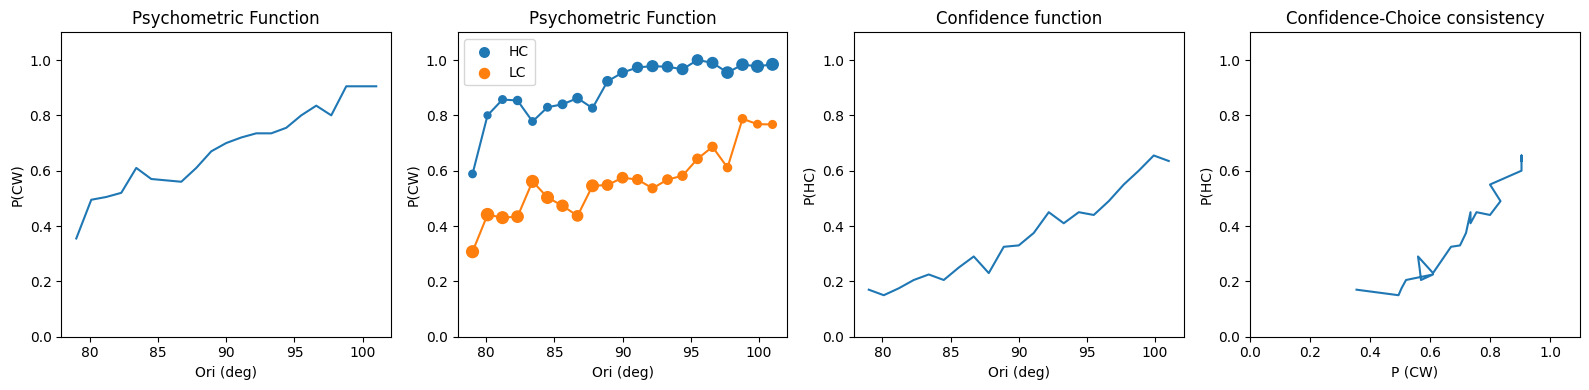

In [54]:
plt.figure(figsize=(16, 4))  # width=16 inches, height=4 inches

plt.subplot(1, 4, 1)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, psycFns[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 2)  # second subplot
plt.scatter(uniqStimOris, psycFns[1, :], s=100*choiceCounts[0,:])
plt.scatter(uniqStimOris, psycFns[2, :], s=100*choiceCounts[1,:])
plt.plot(uniqStimOris, psycFns[1, :])
plt.plot(uniqStimOris, psycFns[2, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')
plt.legend(['HC', 'LC'])

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 3)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, confFn[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(HC)')
plt.title('Confidence function')

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 4)  # 2 rows, 1 column, first subplot
plt.plot(psycFns[0, :], confFn[0, :])
plt.xlabel('P (CW)')
plt.ylabel('P(HC)')
plt.title('Confidence-Choice consistency')

plt.ylim([0, 1.1])        # y-axis limits
plt.xlim([0, 1.1])        # y-axis limits

plt.tight_layout()
plt.show()


In [55]:
# ── Train on damaged V1 data ───────────────────────────────────────────────────────────
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Only fine tuning needed here. Maybe keep learning rate low to avoid catastrophic forgetting of intact V1 performance

In [56]:
# ── training loop ─────────────────────────────────────────────────────────────
n_epochs   = 50 #40
batch_size = 64
n_trials   = len(Y_Decisions)

for epoch in range(n_epochs):
    
    # shuffle each epoch
    perm     = torch.randperm(n_trials)
    X_, Y_   = X_V1Damaged[perm], Y_Decisions[perm]
    
    epoch_loss = 0
    n_correct  = 0

    for i in range(0, n_trials, batch_size):
        x_batch = X_[i : i+batch_size]
        y_batch = Y_[i : i+batch_size]
        
        optimizer.zero_grad()

        z_dec, z_conf, h = model(x_batch)

        # choice loss
        p_choice = torch.where(z_dec > 0, torch.sigmoid(z_dec), 1 - torch.sigmoid(z_dec))
        L_choice = F.binary_cross_entropy_with_logits(z_dec, y_batch)

        # brier loss
        with torch.no_grad():
            #c_target = torch.sigmoid(2.0 * z_dec.abs())
            correct = ((z_dec > 0).float() == y_batch).float()
            lossWeights = torch.where(correct == 1, 20, 20) #18.8, 40
        c_hat    = torch.sigmoid(z_conf)
        L_conf   = torch.mean(lossWeights * ( (correct - c_hat)**2 )) #F.mse_loss(c_hat, correct)

        loss = L_choice + L_conf 
        loss.backward() # compute gradient
        nn.utils.clip_grad_norm_(model.parameters(), 1.0) # normalize gradients
        optimizer.step() # Update weights
        
        epoch_loss += loss.item()
        n_correct  += ((z_dec > 0).float() == y_batch).sum().item()
    
    acc = n_correct / n_trials
    print(f"Epoch {epoch+1:3d} | loss: {epoch_loss:.4f} | acc: {acc:.3f}")


Epoch   1 | loss: 360.7668 | acc: 0.695
Epoch   2 | loss: 315.3198 | acc: 0.726
Epoch   3 | loss: 281.6161 | acc: 0.748
Epoch   4 | loss: 274.9431 | acc: 0.754
Epoch   5 | loss: 262.6421 | acc: 0.769
Epoch   6 | loss: 271.3100 | acc: 0.750
Epoch   7 | loss: 261.6789 | acc: 0.767
Epoch   8 | loss: 252.0495 | acc: 0.774
Epoch   9 | loss: 248.7985 | acc: 0.775
Epoch  10 | loss: 252.0928 | acc: 0.762
Epoch  11 | loss: 240.1329 | acc: 0.778
Epoch  12 | loss: 238.6503 | acc: 0.788
Epoch  13 | loss: 236.8308 | acc: 0.788
Epoch  14 | loss: 243.9398 | acc: 0.780
Epoch  15 | loss: 236.7662 | acc: 0.781
Epoch  16 | loss: 232.4157 | acc: 0.789
Epoch  17 | loss: 231.9249 | acc: 0.786
Epoch  18 | loss: 226.8628 | acc: 0.793
Epoch  19 | loss: 226.3246 | acc: 0.793
Epoch  20 | loss: 239.1389 | acc: 0.781
Epoch  21 | loss: 233.4523 | acc: 0.783
Epoch  22 | loss: 221.5466 | acc: 0.793
Epoch  23 | loss: 221.7460 | acc: 0.797
Epoch  24 | loss: 217.9088 | acc: 0.797
Epoch  25 | loss: 217.7237 | acc: 0.798


In [57]:
# ── Load test data ───────────────────────────────────────────────────────────
spikeDataV1DamagedTest  = dataTest['dataTest']['spikesV1DamagedTest']
tralStimVector          = data['data']['trlStimVector']

tralStimVector = np.rad2deg(tralStimVector)
correctLabels  = (tralStimVector > 90).astype(int)

spikesV1DamagedTest = np.zeros((len(spikeDataV1DamagedTest), len(spikeDataV1DamagedTest[1]), len(spikeDataV1DamagedTest[1][1])))
for i in range(len(spikeDataV1DamagedTest)):
    _spkData = spikeDataV1DamagedTest[i]
    spikesV1DamagedTest[i, :, :] = _spkData.T

# Data structure to use
spikesV1DamagedTest = spikesV1DamagedTest.astype(int) # ntrials x ntimePoints x nNeurons
labels = correctLabels

# make sure shapes are correct
spikesV1DamagedTest = spikesV1DamagedTest.astype(np.float32)   # (4000, 200, 200)
labels = labels.astype(np.float32).squeeze()  # (4000,)

# ── to tensors ────────────────────────────────────────────────────────────────
X_V1DamagedTest = torch.tensor(spikesV1DamagedTest)   # (4000, 200, 200)
Y_Decisions     = torch.tensor(labels)   # (4000,)

In [58]:
# ── Evaluate model ───────────────────────────────────────────────────────────
model.eval()   # turns off dropout etc. (good habit even if you don't have them)

with torch.no_grad():   # no gradient computation needed
    z_dec, z_conf, h = model(X_V1DamagedTest)

# ── convert to numpy ──────────────────────────────────────────────────────────
p_conf = torch.sigmoid(z_conf).numpy()  # (4000,)  in [0,1]
z_dec  = z_dec.numpy()                  # (4000,)  raw decision variable
z_conf = z_conf.numpy()                 # (4000,)  raw confidence variable

choice     = (z_dec > 0).astype(float)      # (4000,)  binary decision {0,1}
confidence = torch.sigmoid(torch.tensor(z_conf)).numpy()  # (4000,)  in [0,1]

print(z_dec.shape, confidence.shape)
print(f"Mean confidence: {confidence.mean():.3f}")
print(f"Prop HC: {(confidence > Cc).sum()/len(confidence):.3f}") # Is probability of correct bounded by 0.5?
print(f"Overall accuracy: {(choice == Y_Decisions.numpy()).mean():.3f}")


(4200,) (4200,)
Mean confidence: 0.802
Prop HC: 0.496
Overall accuracy: 0.761


In [59]:
# ── Psychometric curve and confidence curve ───────────────────────────────────────────────────────────
uniqStimOris = np.rad2deg(data['data']['uniqStimOris'])

confFn       = np.zeros([1, len(uniqStimOris)])
psycFns      = np.zeros([3, len(uniqStimOris)]) # Combined, HC, LC
choiceCounts = np.zeros([4, len(uniqStimOris)]);

for i in range(len(uniqStimOris)):
    ori = uniqStimOris[i]
    fltIdx = tralStimVector == ori

    fltRNNDecisions = choice[fltIdx]
    fltRNNConf      = confidence[fltIdx]

    # Confidence function
    #confFn[0, i]  = np.mean(fltRNNConf) # Mean confidence level
    confFn[0, i]  = (fltRNNConf > Cc).sum() / len(fltRNNConf) # P(HC)
    
    # Psychometric function
    percent_CW    = (fltRNNDecisions == 1).astype(int).sum()/ len(fltRNNDecisions)
    psycFns[0, i] = percent_CW; 

    percent_CW_HC = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).astype(int).sum() / (fltRNNConf > Cc).astype(int).sum()
    percent_CW_LC = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).astype(int).sum() / (fltRNNConf <= Cc).astype(int).sum()
    psycFns[1, i] = percent_CW_HC
    psycFns[2, i] = percent_CW_LC

    choiceCounts[0, i] = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum() #(CW, HC)
    choiceCounts[1, i] = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum() #(CW, LC)
    choiceCounts[2, i] = ( (fltRNNDecisions == 0) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum();  #(CCW, HC)
    choiceCounts[3, i] = ( (fltRNNDecisions == 0) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum(); #(CCW, LC)

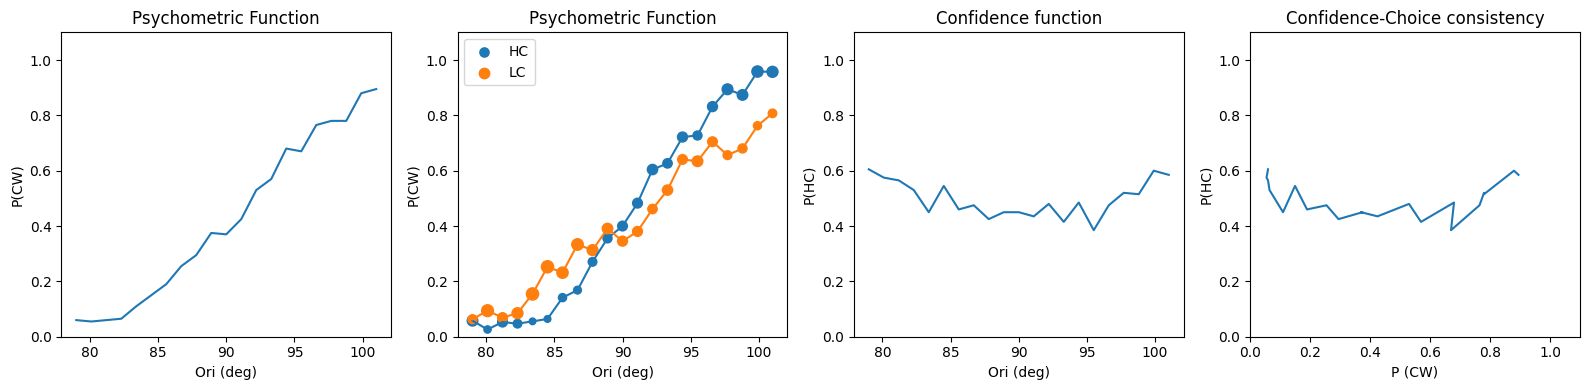

In [60]:
plt.figure(figsize=(16, 4))  # width=16 inches, height=4 inches

plt.subplot(1, 4, 1)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, psycFns[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 2)  # second subplot
plt.scatter(uniqStimOris, psycFns[1, :], s=100*choiceCounts[0,:])
plt.scatter(uniqStimOris, psycFns[2, :], s=100*choiceCounts[1,:])
plt.plot(uniqStimOris, psycFns[1, :])
plt.plot(uniqStimOris, psycFns[2, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')
plt.legend(['HC', 'LC'])

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 3)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, confFn[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(HC)')
plt.title('Confidence function')

plt.ylim([0, 1.1])        # y-axis limits

plt.subplot(1, 4, 4)  # 2 rows, 1 column, first subplot
plt.plot(psycFns[0, :], confFn[0, :])
plt.xlabel('P (CW)')
plt.ylabel('P(HC)')
plt.title('Confidence-Choice consistency')

plt.ylim([0, 1.1])        # y-axis limits
plt.xlim([0, 1.1])        # y-axis limits

plt.tight_layout()
plt.show()
